In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spikes_proxy_funcs import datasets, processing, rate_analysis
from scipy.signal import savgol_filter

In [2]:
data = datasets.load_selected_data(num_datasets='all', num_neurons_per_dataset='all')

In [25]:
# --- STEP 1: Setup ---
# Initialize with your original dictionary
db = datasets.NeuroDataManager(data)

# --- STEP 2: Use in your analysis ---
# Get data for Dataset 9, Neuron 34
times, dff, spikes = db.get_neuron_data(ds_num=1, neuron_idx=4)

# Pass it to your separate function
ups_signal, ups_spikes, ups_evenly_times = processing.upsample_v2(times, dff, spikes, new_rate=1000, do_plot=False)

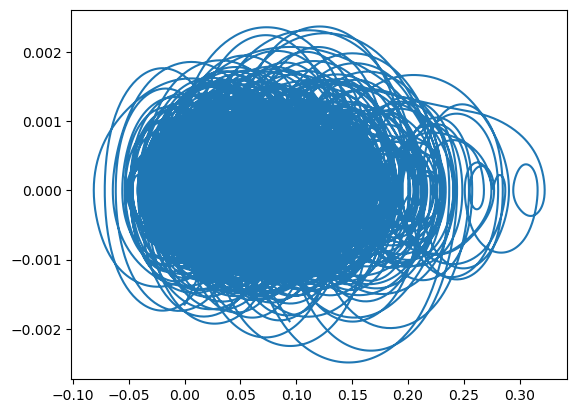

In [26]:
smooth_ups_signal = savgol_filter(ups_signal, 51, 3)
smooth_ups_deriv = savgol_filter(ups_signal, 51, 3, deriv=1)
plt.plot(smooth_ups_signal, smooth_ups_deriv)

In [27]:
cut_smooth_ups_signal, cut_smooth_ups_deriv, mask = rate_analysis.cut_spikes(ups_spikes, smooth_ups_signal, smooth_ups_deriv)

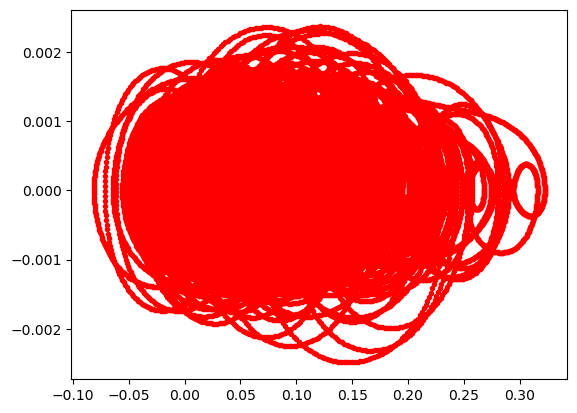

In [28]:
plt.plot(cut_smooth_ups_signal, cut_smooth_ups_deriv, 'r.')

In [29]:
np.polyfit(smooth_ups_signal, smooth_ups_deriv, deg=1)

array([ 2.16507255e-06, -5.13527746e-07])

In [19]:
1/-5.26236949e-05

-19002.84656750699

In [23]:
def debug_visual_check(dataset_dict, ds_key, neuron_idx, new_rate=500):
    neuron_data = dataset_dict[ds_key][neuron_idx]
    t_orig = neuron_data['t']
    dff_orig = neuron_data['dff']
    spk_orig = neuron_data['spikes']
    
    # Process
    sig_v1, spk_v1 = processing.upsample(t_orig, dff_orig, spk_orig, new_rate)
    sig_v2, spk_v2, t_v2 = processing.upsample_v2(t_orig, dff_orig, spk_orig, new_rate)

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    # 1. ORIGINAL RAW DATA
    axes[0].plot(t_orig, dff_orig, 'o-', color='gray', alpha=0.5, markersize=3, label='Raw dF/F (Uneven)')
    axes[0].eventplot(spk_orig, lineoffsets=np.min(dff_orig)-0.05, linelengths=0.05, color='black')
    axes[0].set_title(f"1. ORIGINAL DATA (Raw Timestamps)\nNeuron {neuron_idx} from {ds_key}")
    axes[0].set_ylabel("dF/F")
    axes[0].legend()

    # 3. V2 (The Improved Function)
    axes[1].plot(t_v2, sig_v2, color='tab:blue', label='V2 (Upsampled)')
    axes[1].eventplot(spk_v2, lineoffsets=np.min(sig_v2)-0.05, linelengths=0.05, color='black')
    axes[1].set_title("3. IMPROVED FUNCTION (V2)\nNote: X-axis is Real Time (s). Signal and Spikes match the Raw Data exactly.")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel("dF/F")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Example call:
# debug_visual_check(your_data, 'DS01-OGB1-m-V1', 0, new_rate=500)

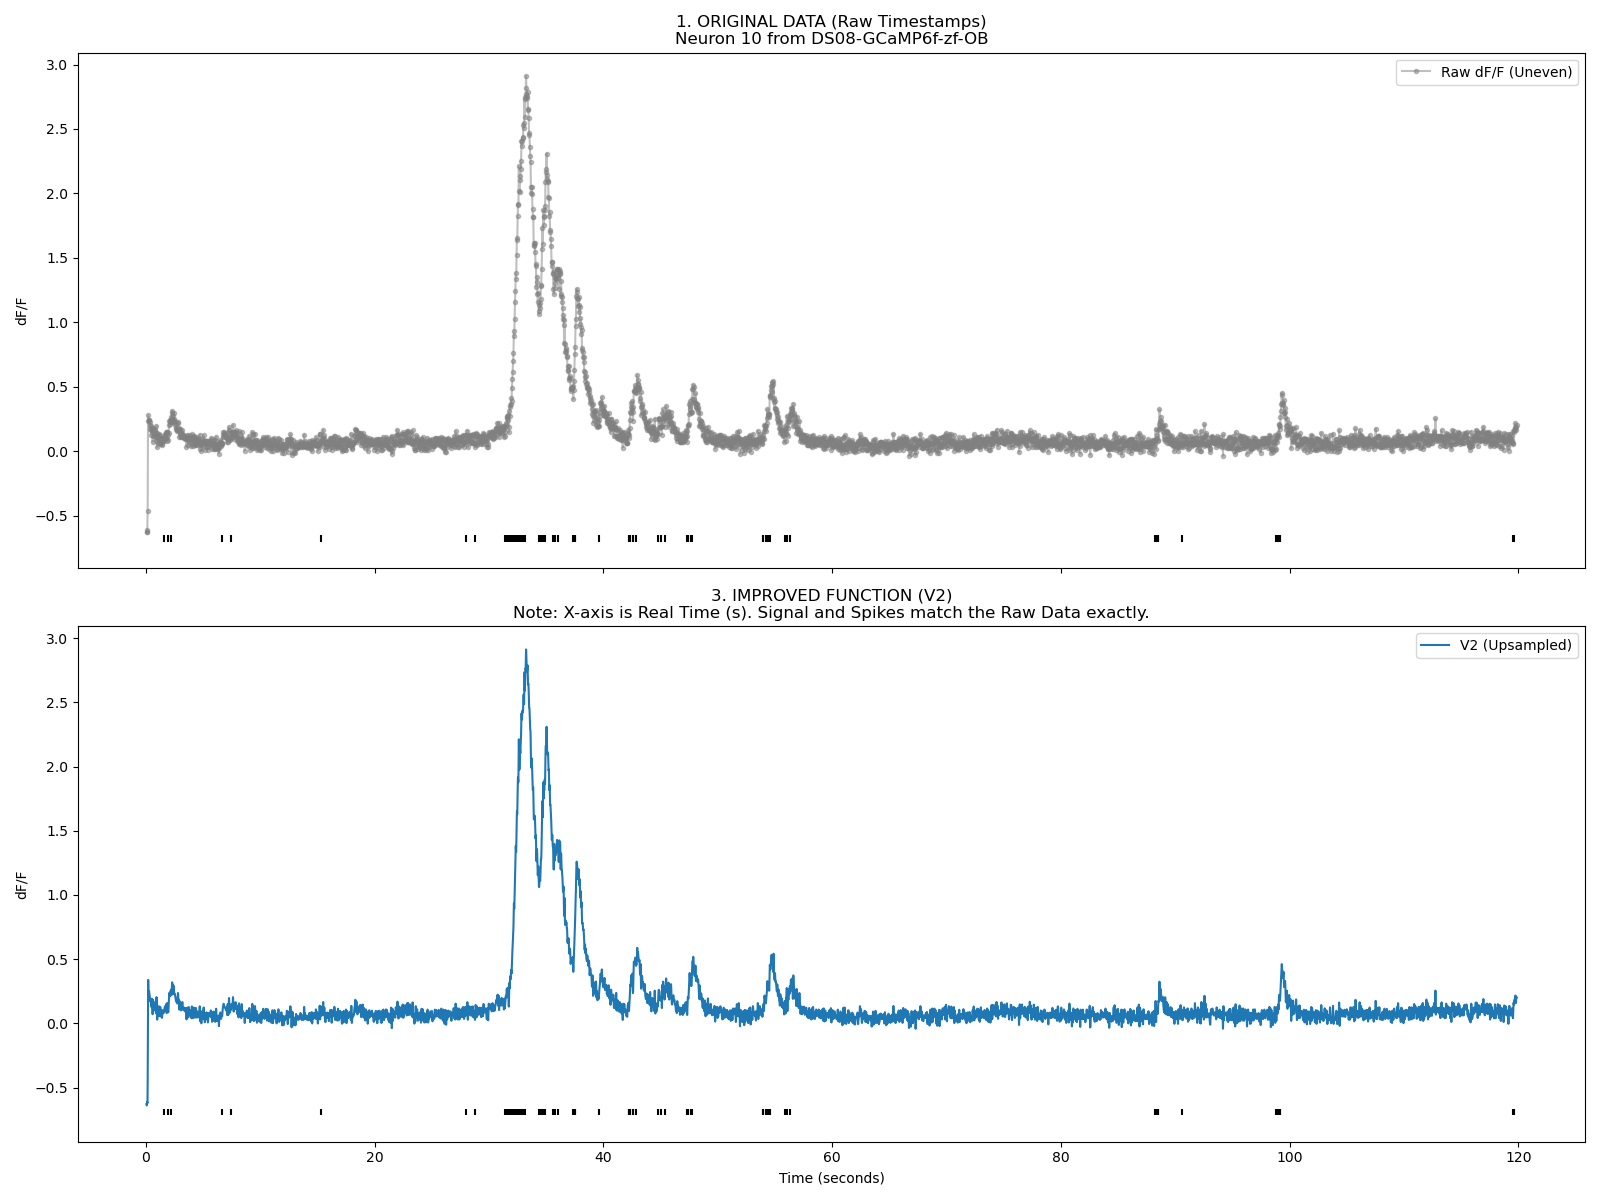

In [29]:
debug_visual_check(data, 'DS08-GCaMP6f-zf-OB', 10, new_rate=500)